In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import sys
from pathlib import Path
import jax as jx
import time
import h5py





riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)

data = '/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/hires-nufft'
data_waspi = '/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/raw0-waspinufft'
save_dir = "/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Results/3D Data/Testing_lam"

# Goal of the notebook: Demonstrate successful infilling of a 3d dataset with ALS

### 1. Import images of WASPI and hires data

- `!riesling op-nufft {data}.h5 {data}-waspinufft.h5 -v2`
- `!riesling op-nufft {data}.h5 {data}-nufft.h5 -v2`

In [6]:
def h5tonum(file, showshape=False, load_traj=True, stripdims=True):
    with h5py.File(file) as f:
        d = f['data'][:]
        if stripdims:
            d = d[0, :, 0]
        if load_traj:
            traj = np.moveaxis(f['trajectory'][:], -1, 0)
            if showshape:
                print(d.shape)
                print(traj.shape)
            return d, traj
        else:
            if showshape:
                print(d.shape)
            return d


riesling_im, _ = h5tonum(f'{data}.h5', showshape=True)
waspi_im, _ = h5tonum(f'{data_waspi}.h5', showshape=True)

(44, 126, 126, 126)
(3, 16128, 122)
(44, 126, 126, 126)
(3, 16896, 122)


In [12]:
width=4
gap = 3
num_iters = 50


inner_wid=26
indiv2 = int(inner_wid/2)



cy = cx = cz = inner_wid // 2
r = 3
yy, xx, zz = np.ogrid[:inner_wid, :inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 + (zz - cz)**2 > r**2 + 2




innersidelen=inner_wid
sidelencart = 13
sidelenrad = 7

### Preparatory and penultimate Operations

1. `zeropadding3d`: Zero pad in image space to an enlarged grid, allowing for finer sampling
    - option to put in image space grid and output image space grid

2. `inner_region`: Select inner region of kspace to be used for lifting(hankel) operation

3. `rebuild3d`: Rebuild the full dataset after unlifting
    - Involves 
        - 1. `jigsaw3d` Jigsaw the inner region back in to the enlarged kspace
        - 2. Un-zeropadding in image space

In [7]:
def zeropadding3d(data, im_dim, input_kspace=True, output_kspace=True):
    """Zero pad of kspace
    
            Args:
                data: Dataset in cartesian coordinates (n_coils, nx, ny)
                im_dim: Requested output dimensions
                input_kpsace: True if data is a kspace array
                output_kpsace: True if wanting kspace output
    
            Returns:
                Zeropadded data of requested domain
        """
    # NOTE: Give options to input and output kspace in order to save computation
    n_coils = data.shape[0]
    print('starting resize')
    if input_kspace:
        enlarged_image_grid = sp.resize(sp.ifft(data,axes=(-3, -2, -1)), [n_coils,im_dim, im_dim, im_dim])
        print('fft done input zp')
    else:
        enlarged_image_grid = sp.resize(data, [n_coils,im_dim, im_dim, im_dim])
    if output_kspace:
        enlarged_cartesian_kspace = sp.fft(enlarged_image_grid, axes=(-3, -2, -1))
        print('fft done output zp')
        return enlarged_cartesian_kspace
    else:
        return enlarged_image_grid


def inner_portion(enlarged_kspace, inner_sidelen):
    """Take an inner cube of kspace to speed up the hankel loop

        Args:
            enlarged_kspace: Zero padded kspace in cartesian coordinates (n_coils, nx, ny)
            inner_sidelen: Side legnth of the inner square, divided by 2 to find from central point outward

        Returns:
            isolated_kspace: Inner kspace array
            isolation_mask: Mask of the inner region to use when 'jigsawing' the transformed array back in
            Start: xy index of the enlarged array that the inner region starts at
            End: xy index of the enlarged array that the inner region ends at
    """

    cx, cy, cz = enlarged_kspace.shape[1] // 2, enlarged_kspace.shape[2] // 2, enlarged_kspace.shape[3] // 2
    N = inner_sidelen/2
    start, end = int(cx-N), int(cx+N)
    isolation_mask = np.ones(enlarged_kspace.shape[1:], dtype=int)
    isolation_mask[start:end, start:end, start:end] = 0
    isolated_kspace = enlarged_kspace[:, start:end, start:end, start:end]
    
    return(isolated_kspace, start, end)

def jigsaw3d(output_kspace, enlarged_kspace, inner_start, inner_end):
    """Place the transformed kspace inner array back into the full zeropadded data, analogous to placing a jigsaw piece
        
                Args:
                    output_kspace: Unlifted array
                    enlarged_kspace: Full Zeropadded enlarged kspace data
                    inner_start: Index of where the start of the transformed array should be slotted into the enlarged array
                    inner_end: Index of where the end of the transformed array should be slotted into the enlarged array
        
                Returns:
                    Data of equal dims to the enlarged_kspace, with output_kspace placed between inner_start and inner_end
            """
    enlarged_kspace[:, inner_start:inner_end, inner_start:inner_end, inner_start:inner_end] = output_kspace
    return(enlarged_kspace)

def rebuild3d(output_kspace, enlarged_kspace, inner_start, inner_end, im_dim, output_kspacearr):
    """Post ALS return the filled in cartesian data
        
                Args:
                    output_kspace: Unlifted array: Passed to jigsaw3d
                    enlarged_kspace: Full Zeropadded enlarged kspace data: Passed to jigsaw3d
                    inner_start: Index of where the start of the transformed array should be slotted into the enlarged array: Passed to jigsaw3d
                    inner_end: Index of where the end of the transformed array should be slotted into the enlarged array: Passed to jigsaw3d
                    im_dim: Requested output dimensions. SHOULD MATCH SAME AS ORIGINAL ARRAY
                    output_kspacearr: TRUE if wanting kspace output, FALSE if wanting image space output: Passed zeropadding3d
                Returns:
                    filled_ksp: In filled data of image or kspace
            """ 

    recombined = jigsaw3d(output_kspace=output_kspace, inner_start=inner_start, inner_end=inner_end, enlarged_kspace=enlarged_kspace)
    print("jigsaw3d done")
    filled_ksp = zeropadding3d(recombined, im_dim, output_kspace=output_kspacearr)
    return(filled_ksp)

In [8]:
def hankel(kspace, w):
    N_c = kspace.shape[0]
    N_x = kspace.shape[1] - w + 1
    N_y = kspace.shape[2] - w + 1
    N_z = kspace.shape[3] - w + 1
    data_matrix = np.empty((N_c * w*w*w, N_x*N_y*N_z), dtype=np.complex64)
    for c in range(N_c):
        onecoil_matrix = data_matrix[c*w*w*w:(c+1)*w*w*w]
        col_index = 0
        for k in range(N_z):
            for i in range(N_y):
                for j in range(N_x):
                    mat = kspace[c, j:j+w, i:i+w, k:k+w]
                    onecoil_matrix[:, col_index] = mat.reshape(-1, order='F')
                    col_index += 1
    return data_matrix, N_c, N_x, N_y, N_z


def hankel_H_averaged(data_matrix, n_coils, Nx, Ny, Nz, w=3):
    kspace = np.empty((n_coils, Nx, Ny, Nz), dtype=np.complex64)
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1
    n_win_z = Nz - w + 1

    for c in range(n_coils):
        singlecoil = split_arr[c]
        transposed = singlecoil.T

        recon = np.zeros((Nx, Ny, Nz), dtype=np.complex64)
        counts = np.zeros((Nx, Ny, Nz), dtype=np.float32)

        for index in range(len(transposed)):
            win = transposed[index].reshape((w, w, w), order='F')

            j = index % n_win_x
            i = (index // n_win_x) % n_win_y
            k = index // (n_win_x * n_win_y)

            recon[j:j+w, i:i+w, k:k+w] += win
            counts[j:j+w, i:i+w, k:k+w] += 1

        kspace[c] = recon / counts
    return kspace

In [9]:
def softimpute_ALS(X_H, M_H, rank, lamda, n_iters, seed):
        print("starting ALS")
        D = np.eye(rank, dtype=np.complex64)
        m,n = np.shape(X_H)
        rng = np.random.default_rng(seed)
        U = rng.standard_normal((m, rank)) + 1j * rng.standard_normal((m, rank))
        V = np.zeros((n, rank),dtype=np.complex64)
        U, _ = np.linalg.qr(U)


        A = np.dot(U,D)
        B = np.dot(V,D)
        iter_count = 0
        ABt = A @ B.conj().T
        norms = {'A': [], 'B': [], 'ABt': [], 'X_star': [], 'rel_change': [], 'residual': []}
        print("starting ALS iters")
        while iter_count < n_iters:
            ABt_prev = ABt
            X_star = np.where(M_H, X_H, ABt)
            B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*D)
            ABt = A @ B.conj().T
    
            X_star = np.where(M_H, X_H, ABt)
            A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*D)
            ABt = A @ B.conj().T

            norms['A'].append(np.linalg.norm(A))
            norms['B'].append(np.linalg.norm(B))
            norms['ABt'].append(np.linalg.norm(ABt))
            norms['X_star'].append(np.linalg.norm(X_star))
            norms['rel_change'].append(np.linalg.norm(ABt - ABt_prev) / np.linalg.norm(ABt))
            norms['residual'].append(np.linalg.norm(ABt - X_star))

            ABt = A @ B.conj().T
            iter_count += 1
            print(f'iter {iter_count} done')
        return(ABt, norms)





def LORAKS_imputeals(n_iters, window_size, cartesian_inputkspace, dtg_mask, rank, lamda, enlarged_kspace, inner_start, inner_end, im_dim, seed):
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_forhankel = ksp_forhankel * dtg_mask

    hankel_matrix, *_  = hankel(kspace=ksp_forhankel, w=window_size)
    masked_hankel = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
    masked_hankel, *_ = hankel(kspace=masked_hankel, w=window_size)
    masked_hankel = np.real(masked_hankel) > 0.5

    t_als_start = time.perf_counter()
    filled_hankel, norms = softimpute_ALS(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lamda, n_iters=n_iters, seed=seed)
    t_als = time.perf_counter() - t_als_start
    print(f"ALS Done ({t_als:.3f}s)")

    kspace_cart_coils_recon = hankel_H_averaged(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], Nz=ksp_forhankel.shape[3],w=window_size)

    kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    filled_ksp = rebuild3d(output_kspace=kspace_cart_coils_recon,inner_start= inner_start,inner_end= inner_end, enlarged_kspace= enlarged_kspace,im_dim=im_dim)

    return (filled_ksp, norms)



def LORAKS_imputeals_partial(n_iters, window_size, cartesian_inputkspace, dtg_mask, rank, lamda, seed, savehankel=False, savefilledhankel=False):
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_forhankel = ksp_forhankel * dtg_mask

    hankel_matrix, *_  = hankel(kspace=ksp_forhankel, w=window_size)
    masked_hankel = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
    masked_hankel, *_ = hankel(kspace=masked_hankel, w=window_size)
    masked_hankel = np.real(masked_hankel) > 0.5
    if savehankel:
        np.save(f"{save_dir}/hankel{r}_win{win}rank{rank}.npy", hankel_matrix)

    t_als_start = time.perf_counter()
    filled_hankel, norms = softimpute_ALS(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lamda, n_iters=n_iters, seed=seed)
    if savefilledhankel:
         np.save(f"{save_dir}/filled_hankel{r}_win{win}rank{rank}.npy", filled_hankel)
    t_als = time.perf_counter() - t_als_start
    print(f"ALS Done ({t_als:.3f}s)")

    kspace_cart_coils_recon = hankel_H_averaged(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], Nz=ksp_forhankel.shape[3],w=window_size)
    kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    
    return (kspace_cart_coils_recon,norms)

## Perfoming the infilling on inner_region

In [17]:
#del enlarged_cartesian
d = np.load(f"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Results/3d Data/inner_cache.npy.npz")


inner_region, start, end = d['inner_region'], d['start'], d['end']
rank = 50
lam = 5*10**-5
win = 11
kspace_cart_coils_recon, norms = LORAKS_imputeals_partial(n_iters=25, window_size=win, 
                                                          cartesian_inputkspace=inner_region,dtg_mask=mask, 
                                                          rank=rank, lamda=lam, seed=42, savehankel=True, savefilledhankel=True)
#np.save(f"{save_dir}/kspace_cart_coils_recon_r3_win{win}rank{rank}.npy", kspace_cart_coils_recon)
#np.save(f"{save_dir}/norms_r{r}_win{win}rank{rank}.npy", norms)

starting ALS
starting ALS iters
iter 1 done
iter 2 done
iter 3 done
iter 4 done
iter 5 done
iter 6 done
iter 7 done
iter 8 done
iter 9 done
iter 10 done
iter 11 done
iter 12 done
iter 13 done
iter 14 done
iter 15 done
iter 16 done
iter 17 done
iter 18 done
iter 19 done
iter 20 done
iter 21 done
iter 22 done
iter 23 done
iter 24 done
iter 25 done
ALS Done (146.651s)


## Slotting the infilled kspace back into the enlarged kspace and then recombining and saving

In [ ]:
enlarged_cartesian = np.load(f"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Results/3D Data/enlarged_cartesian.npy")
d = np.load(f"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Results/3d Data/inner_cache.npy.npz")


inner_region, start, end = d['inner_region'], d['start'], d['end']
kspace_cart_coils_recon = np.load(f"{save_dir}/kspace_cart_coils_recon_r3_win{win}rank{rank}.npy")
filled_ksp = rebuild3d(output_kspace=kspace_cart_coils_recon, inner_start=start, inner_end=end,enlarged_kspace=enlarged_cartesian, im_dim=126, output_kspacearr=False)

np.save(f"{save_dir}/im_filled_r3_win{win}rank{rank}.npy", filled_ksp)

Text(0.5, 1.0, 'Unfilled')

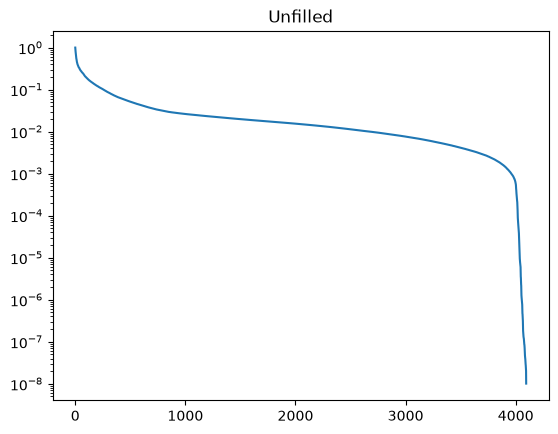

In [4]:
rank = 50
lam = 5*10**-5
win = 11
r=3
unfilledhankel = np.load(f"{save_dir}/hankel{r}_win{win}rank{rank}.npy")

sv = jx.numpy.linalg.svd(unfilledhankel, compute_uv=False)
plt.semilogy(sv / sv[0])
plt.title('Unfilled')

Text(0.5, 1.0, 'Filled')

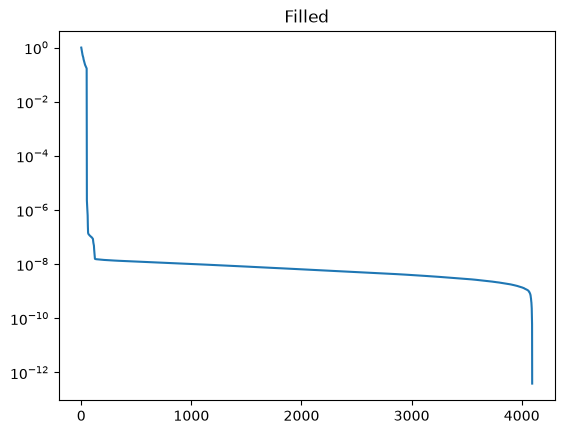

In [5]:
rank = 50
lam = 5*10**-5
win = 11
filed = np.load(f"{save_dir}/filled_hankel{r}_win{win}rank{rank}.npy")

import matplotlib.pyplot as plt

#s = np.linalg.svd(kspace_cart_coils_recon, compute_uv=False)

sv = jx.numpy.linalg.svd(filed, compute_uv=False)
plt.semilogy(sv / sv[0])
plt.title('Filled')

## Plotting for comparison

- ensure `waspi_im` matches what you want to compare it to

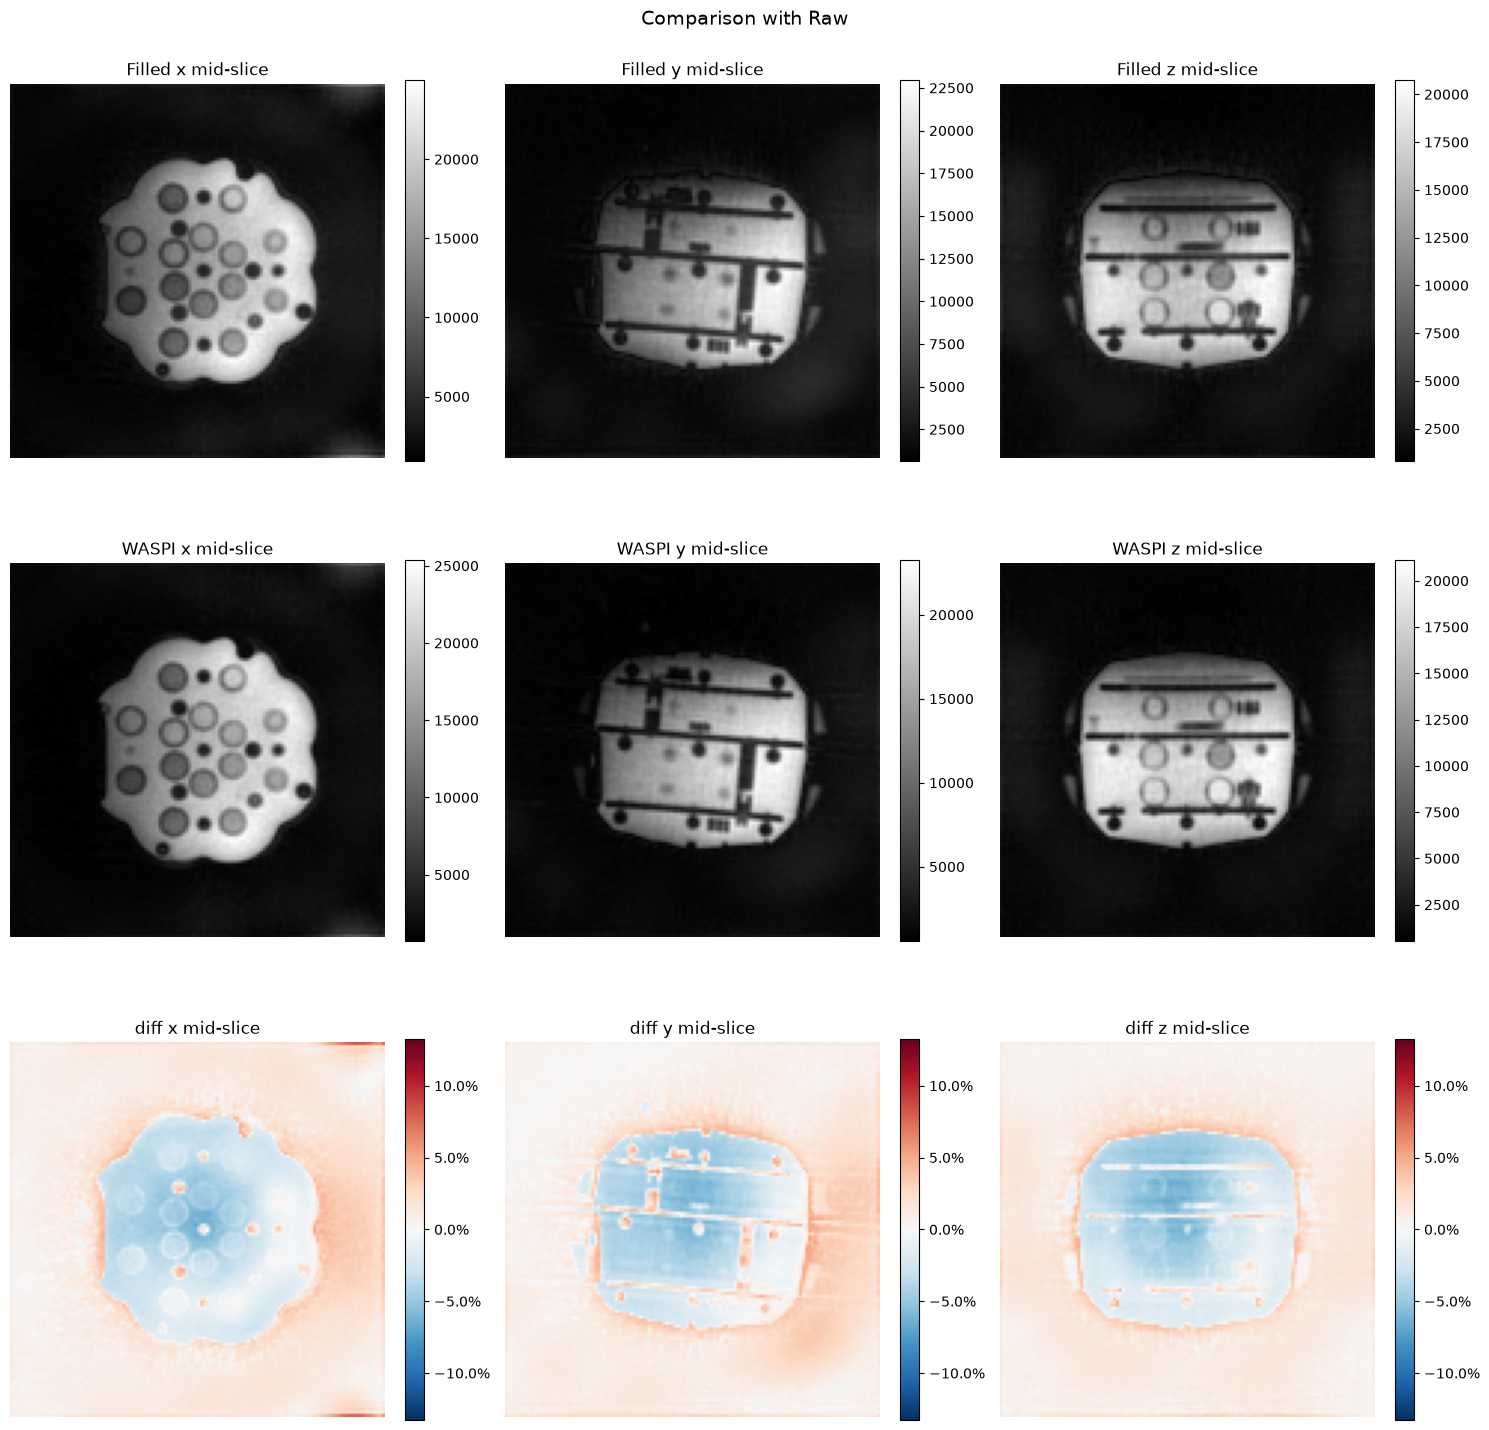

In [ ]:
import matplotlib.ticker as mticker

r=3
filled_imgrid = np.load(f"{save_dir}/im_filled_r3_win{win}rank{rank}.npy")

recon_rss = np.sum(np.abs(filled_imgrid)**2, axis=0)**0.5
ref_rss   = np.sum(np.abs(waspi_im)**2, axis=0)**0.5
diff_rss = (recon_rss - ref_rss) / np.max(np.abs(recon_rss))

nx, ny, nz = recon_rss.shape
slices = lambda v: [
    (v[nx // 2, :, :], 'x mid-slice'),
    (v[:, ny // 2, :], 'y mid-slice'),
    (v[:, :, nz // 2], 'z mid-slice'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Comparison with Raw', fontsize=14)
rows = [('Filled', recon_rss, 'gray'),
        ('WASPI',   ref_rss,   'gray'),
        ('diff',  diff_rss,  'RdBu_r')]

for row_axes, (label, vol, cmap) in zip(axes, rows):
    vmax = np.abs(diff_rss).max() if label == 'diff' else None
    for ax, (sl, title) in zip(row_axes, slices(vol)):
        kw = dict(cmap=cmap)
        if label == 'diff':
            kw.update(vmin=-vmax, vmax=vmax)
        im = ax.imshow(sl, **kw)
        ax.set_title(f'{label} {title}')
        ax.axis('off')
        cbar = fig.colorbar(im, ax=ax, fraction=0.046)
        if label == 'diff':
            cbar.formatter = mticker.PercentFormatter(xmax=1.0, decimals=1)
            cbar.update_ticks()
#plt.savefig('Comparison to RAW.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
norms_file = f"{save_dir}/norms_r{r}_win{win}rank{rank}.npy"
norms = np.load(norms_file, allow_pickle=True).item()

keys = ['A', 'B', 'ABt', 'X_star', 'rel_change', 'residual']

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
for ax, k in zip(axes.flat, keys):
    vals = norms[k]
    iters = range(1, len(vals) + 1)
    ax.plot(iters, vals, marker='o')
    ax.set_title(k)
    ax.set_xlabel('iteration')
    ax.set_ylabel('change (L2 norm)')
    if k == 'rel_change':
        ax.set_yscale('log')
        ax.set_ylabel('relative change')
    ax.grid(True, alpha=0.3, which='both')

fig.suptitle('Convergence per iteration')
fig.tight_layout()
plt.show()

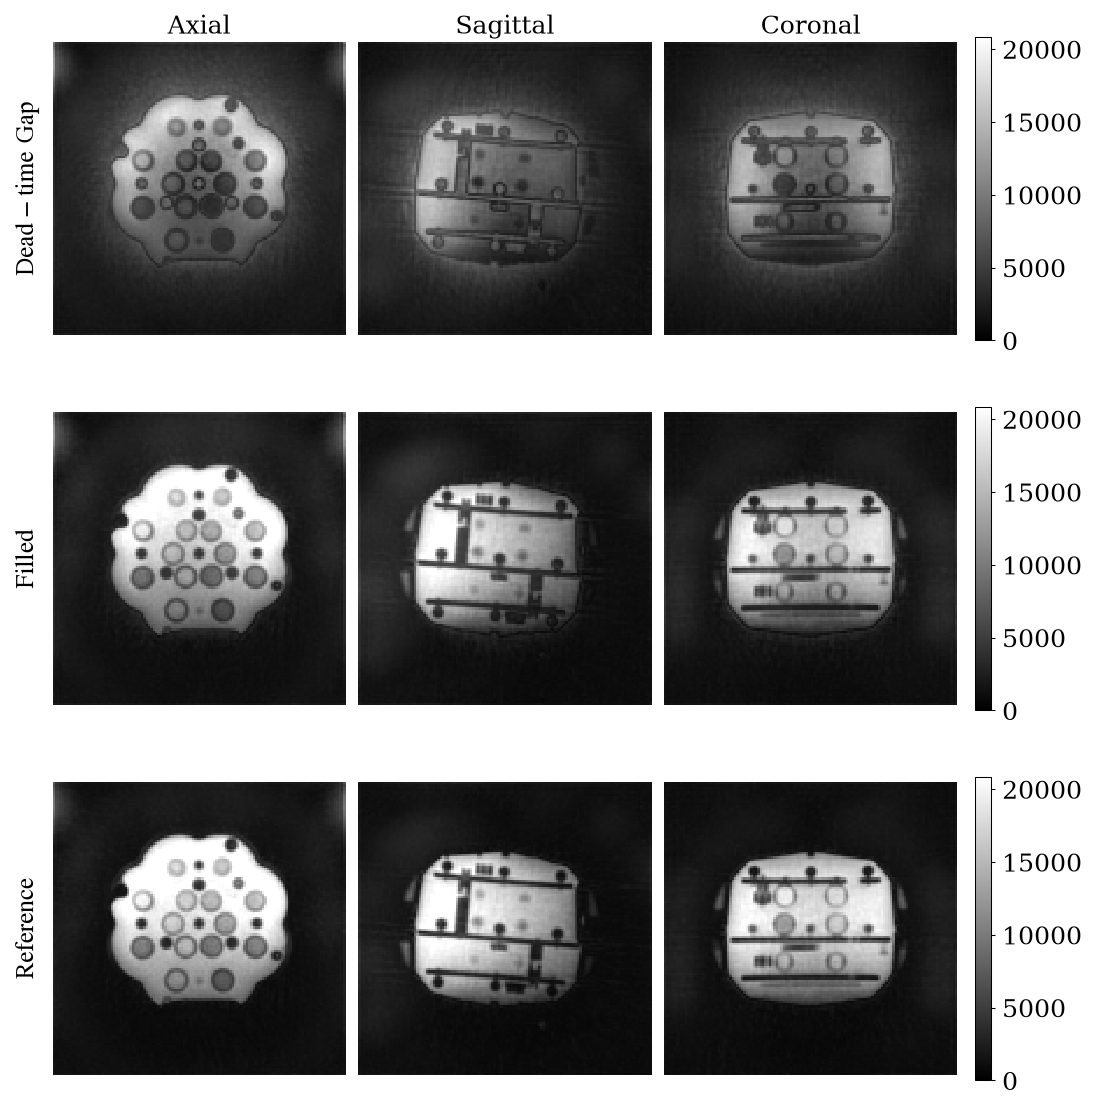

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ---- Publication typography ----
rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.linewidth': 0.6,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'mathtext.fontset': 'stix',
})

# ---- Parameters ----
#r, rank, lam, win = 3, 100, 5e-5, 8
#filled_imgrid = np.load(f"{save_dir}/im_filled_r{r}_win{win}rank{rank}.npy")

# ---- RSS coil combination ----
recon_rss = np.sum(np.abs(filled_imgrid)**2, axis=0)**0.5
ref_rss   = np.sum(np.abs(waspi_im)**2,      axis=0)**0.5
raw_rss   = np.sum(np.abs(riesling_im)**2,   axis=0)**0.5

nx, ny, nz = recon_rss.shape
slices = lambda v: [
    (v[nx // 2, :, :],                             'Axial'),
    (np.rot90(v[:, ny // 2, :][::-1, ::-1], k=-1), 'Sagittal'),
    (np.rot90(v[:, :, nz // 2][::-1, ::-1], k=-1), 'Coronal'),
]

# ---- Shared magnitude scaling ----
mag_vols = [recon_rss, raw_rss, ref_rss]
mag_vmax = np.percentile(np.concatenate([v.ravel() for v in mag_vols]), 99.5)

rows = [
    (r'$\mathrm{Dead-time\ Gap}$', raw_rss,   'gray', 0.0, mag_vmax),
    (r'$\mathrm{Filled}$',         recon_rss, 'gray', 0.0, mag_vmax),
    (r'$\mathrm{Reference}$',      ref_rss,   'gray', 0.0, mag_vmax),
]

fig, axes = plt.subplots(3, 3, figsize=(7.2, 7.4), constrained_layout=True)

for i, (row_axes, (label, vol, cmap, vmin, vmax)) in enumerate(zip(axes, rows)):
    ims = []
    for j, (ax, (sl, view)) in enumerate(zip(row_axes, slices(vol))):
        im = ax.imshow(sl.T, cmap=cmap, vmin=vmin, vmax=vmax,
                       origin='lower', interpolation='nearest', aspect='equal')
        ims.append(im)
        if i == 0:
            ax.set_title(view, fontsize=12, pad=4)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    cbar = fig.colorbar(ims[-1], ax=row_axes, fraction=0.046, pad=0.02,
                        location='right', shrink=0.85)
    cbar.ax.tick_params(labelsize=12, width=0.5, length=2)
    cbar.outline.set_linewidth(0.5)
    row_axes[0].set_ylabel(label, fontsize=12, rotation=90, labelpad=6)
    row_axes[0].yaxis.set_label_position('left')

fig.savefig("Figure 2 - Raw Comparison.pdf", bbox_inches='tight', dpi=600)
plt.show()